In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
#from sklearn.cross_validation import train_test_split

In [2]:
# import some data to play with
iris = datasets.load_iris()

In [3]:
X = iris.data  # we only take the first two features
y = iris.target
target_names = iris.target_names

In [4]:
IsSetosa = (iris.target==0)  #returns an array of True and False, it is True when target is 0 (setosa) 
print('The portion of Setosa is ', IsSetosa.sum()/len(IsSetosa))

The portion of Setosa is  0.3333333333333333


In [5]:
df = pd.DataFrame(iris.data)    #since above codes is for dataframe, we use pandas to change the data into dataframe
df.columns = iris.feature_names #assign the feature names to the dataframe
df['target'] = IsSetosa   #add target labels to the dataframe
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,True
1,4.9,3.0,1.4,0.2,True
2,4.7,3.2,1.3,0.2,True
3,4.6,3.1,1.5,0.2,True
4,5.0,3.6,1.4,0.2,True


In [6]:
#split the data into training set and testing set, and set seed = 0
train, test = train_test_split(df, test_size = 0.1, random_state = 0)
print('Size of the train dataset is ', train.shape)
print('Size of the test dataset is ', test.shape)

Size of the train dataset is  (135, 5)
Size of the test dataset is  (15, 5)


In [7]:
x_train = train.iloc[:, :2]

#Let x in the testing set be the variable without Murder
#Let y in the testing set be Murder
y_train = train['target']
x_test = test.iloc[:, :2]
y_test = test['target']

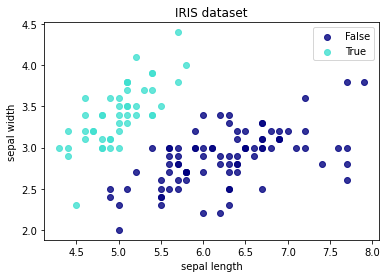

In [8]:
plt.figure() #prepare to plot
colors = ['navy', 'turquoise'] #define colors for future usage
#'zip' maps the similar index of multiple containers so that they can be used just using as single entity.
for color, i, target_name in zip(colors, [0, 1], np.unique(y_train)): 
    plt.scatter(x_train.iloc[:, 0][y_train == i], x_train.iloc[:, 1][y_train == i], alpha=.8, color = color, label = target_name)

plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()
plt.title('IRIS dataset')
plt.show()

### Train hard-margin/soft-margin SVM classifier by using training dataset


In [9]:
#fit soft-margin linear svm to training variables and labels
lin_soft_svc = svm.LinearSVC(C = 1e-5).fit(x_train, y_train)

#fit soft-margin linear svm to training variables and labels
lin_soft_svc_ = svm.LinearSVC(C = 100).fit(x_train, y_train)

#fit hard-margin linear svm to training variables and labels with regularization 
lin_hard_svc = svm.LinearSVC(C = 8000).fit(x_train, y_train)

### Visualize the results


In [10]:
# title for the plots
titles = ['Linear Soft-margin SVM (C~0)', 'Linear Soft-margin SVM (C=100)','Linear Hard-margin SVM (C=8000)']

In [11]:
h = 0.02
# create a mesh to plot in
x_min, x_max = x_train.iloc[:, 0].min() - 1, x_train.iloc[:, 0].max() + 1
y_min, y_max = x_train.iloc[:, 1].min() - 1, x_train.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


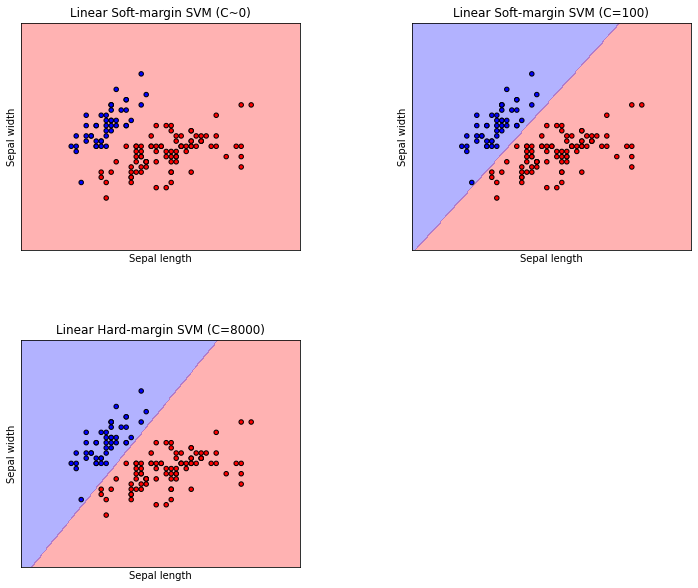

In [12]:
plt.figure(figsize = (12, 10))
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])
for i, model in enumerate((lin_soft_svc, lin_soft_svc_, lin_hard_svc)):
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, m_max]x[y_min, y_max].
    plt.subplot(2, 2, i + 1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cmap_bold, alpha=0.3)

    # Plot also the training points
    plt.scatter(x_train.iloc[:, 0], x_train.iloc[:, 1], c=y_train, cmap=cmap_bold, edgecolor = 'k', s=20)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])

plt.show()

### From above figure, you can find when C is small, some miss-classification is allowed. But when C is large, no miss-classification is allowed.


In [13]:
#get predicted value by using '.predict'
y_predict_hard = lin_hard_svc.predict(x_test)
y_predict_soft = lin_soft_svc.predict(x_test)
y_predict_soft_ = lin_soft_svc_.predict(x_test)

Test Accuracy is 1.000000
Test Accuracy is 0.800000
Test Accuracy is 1.000000


/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


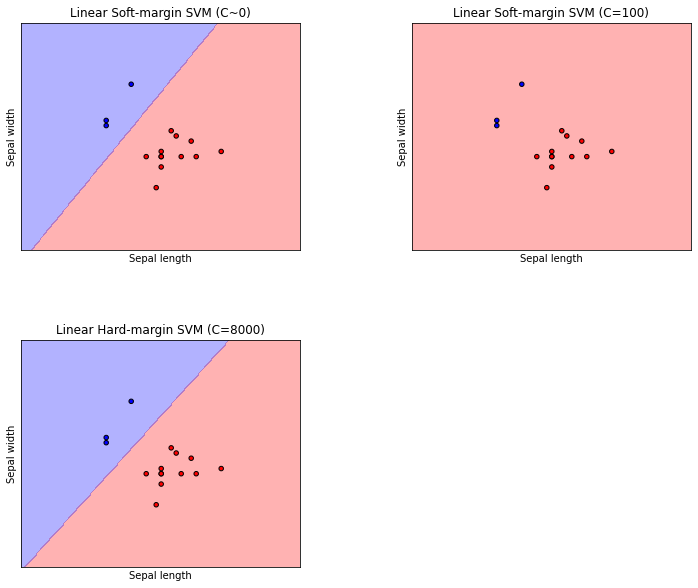

In [14]:
plt.figure(figsize = (12, 10))
for i, model in enumerate((lin_hard_svc, lin_soft_svc, lin_soft_svc_)): #i is the index, and model is one of the three model
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, m_max]x[y_min, y_max].
    plt.subplot(2, 2, i + 1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cmap_bold, alpha=0.3)

    # Plot also the training points
    plt.scatter(x_test.iloc[:, 0], x_test.iloc[:, 1], c=y_test, cmap=cmap_bold, edgecolor = 'k', s=20)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])
    
    y_predict = model.predict(x_test)
    print('Test Accuracy is %f'%accuracy_score(y_predict, y_test))
plt.show()

### Train SVM with different kernels


In [15]:
# we create an instance of SVM and fit out data. We do not scale our
# data since we want to plot the support vectors
C = 1.0  # SVM regularization parameter
rbf_svc = svm.SVC(kernel='rbf', gamma=0.7, C=C).fit(x_train, y_train)
poly_svc = svm.SVC(kernel='poly', degree=3, C=C).fit(x_train, y_train)

In [16]:
# title for the plots
titles = ['SVC with RBF kernel', 'SVC with polynomial (degree 3) kernel']

/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


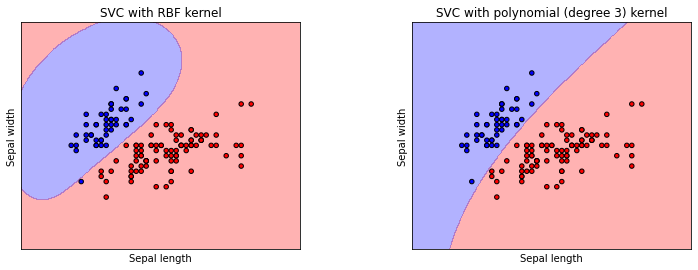

In [17]:
plt.figure(figsize = (12, 10)) #define the size of the figure
for i, model in enumerate((rbf_svc, poly_svc)):  #i is the index, and model is rbf_svc or poly_svc
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, m_max]x[y_min, y_max].
    plt.subplot(2, 2, i + 1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cmap_bold, alpha=0.3)

    # Plot also the training points
    plt.scatter(x_train.iloc[:, 0], x_train.iloc[:, 1], c=y_train, cmap=cmap_bold, edgecolor = 'k', s=20)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])

plt.show()

In [18]:
#predict the label by using  '.predict(x)'
y_test_rbf = rbf_svc.predict(x_test)
y_test_poly = poly_svc.predict(x_test)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


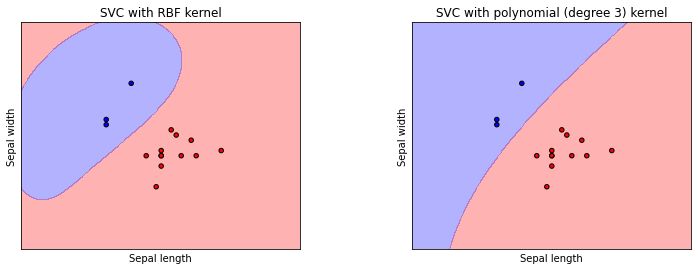

In [19]:
plt.figure(figsize = (12, 10)) #define the size of the figure
for i, clf in enumerate((rbf_svc, poly_svc)):
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, m_max]x[y_min, y_max].
    plt.subplot(2, 2, i + 1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cmap_bold, alpha=0.3)

    # Plot also the training points
    plt.scatter(x_test.iloc[:, 0], x_test.iloc[:, 1], c=y_test, cmap=cmap_bold, edgecolor = 'k', s=20)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])

plt.show()